## Build A Basic Chatbot With Langgraph(GRAPH API)

### State: the graph's shared memory

`State` defines the data that moves between every node in the graph. The `messages` field is annotated with `add_messages`, which is a LangGraph reducer: instead of replacing the old conversation each time a node returns new messages, LangGraph appends the new messages to the existing history. This is what lets each later step see the full conversation so far.


In [1]:
from typing_extensions import TypedDict
from typing import Annotated

from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="qwen/qwen3-32b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7101df6cb230>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7101df6cbcb0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [4]:
llm = init_chat_model("groq:qwen/qwen3-32b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7101df77b890>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7101df4e42d0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### The chatbot node

A LangGraph node is just a Python function that receives the current `state` and returns a partial state update. Here the node sends the current message history to the LLM, then returns the model response under the same `messages` key so `add_messages` can append it to the conversation.


In [5]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

### Building the first graph

This first graph has a single real node: `llmchatbot`. `START` tells LangGraph where execution begins, and `END` tells it where to stop. After `compile()`, the graph becomes runnable with `.invoke()` for a full response or `.stream()` for step-by-step events.


In [6]:
graph_builder = StateGraph(State)
graph_builder.add_node("llmchatbot",chatbot)
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)
graph = graph_builder.compile()

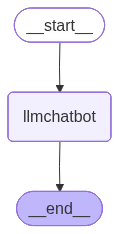

In [7]:
from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
response = graph.invoke({"messages":"hi"})
response

{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='0a96cdae-59af-403c-89e2-6d43a0071757'),
  AIMessage(content='<think>\nOkay, the user said "hi". I should respond in a friendly and welcoming way. Let me make sure to keep it open-ended so they feel comfortable to ask anything. Maybe add an emoji to keep it approachable. Let me check for any typos. All looks good. Ready to send.\n</think>\n\nHi! 😊 How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 77, 'prompt_tokens': 9, 'total_tokens': 86, 'completion_time': 0.173703198, 'completion_tokens_details': None, 'prompt_time': 0.000203707, 'prompt_tokens_details': None, 'queue_time': 0.053208522, 'total_time': 0.173906905}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ddab9-dd04-7780-adba-43d4938ff5c8-0', tool_c

In [9]:
response["messages"][-1].content

'<think>\nOkay, the user said "hi". I should respond in a friendly and welcoming way. Let me make sure to keep it open-ended so they feel comfortable to ask anything. Maybe add an emoji to keep it approachable. Let me check for any typos. All looks good. Ready to send.\n</think>\n\nHi! 😊 How can I assist you today?'

In [10]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user asked, "Hi How are you?" I need to respond appropriately. First, I should acknowledge their greeting and offer a friendly reply. Since I'm an AI, I don't have real feelings, but I should express it in a way that is close and natural. I can say I'm doing well and ask about their day. I should keep it conversational and open-ended to encourage them to share more. Also, make sure the tone is warm and approachable. Let me check if there's anything else I need to consider. Maybe add an emoji to keep it friendly. Yeah, that should work.
</think>

Hello! I'm doing well, thanks for asking! 🌟 How about you? I'd love to hear how your day is going!


### Adding external tools

Tools give the model actions it cannot perform by text generation alone. `TavilySearch` lets the agent fetch web search results, while the custom `multiply` function shows how normal Python functions can become tools when they have clear type hints and a useful docstring.


In [11]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=2)
tavily_tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://huggingface.co/learn/agents-course/unit2/langgraph/when_to_use_langgraph',
   'title': 'What is LangGraph ? · Hugging Face',
   'content': '`LangGraph` is a framework developed by LangChain **to manage the control flow of applications that integrate an LLM**. ## Is LangGraph different from LangChain ? The classes from LangChain might be used in LangGraph, but do not HAVE to be used. The packages are different and can be used in isolation, but, in the end, all resources you will find online use both packages hand in hand. `LangGraph` is on the other end of the spectrum, it shines when you need **“Control”** on the execution of your agent. LangGraph is particularly valuable when you need **Control over your applications**. It gives you the tools to build an application that follows a predictable process while still leveraging the power of LLMs. Put simply, if your ap

In [12]:
## custom function tool 
def multiply(a :int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

### Binding tools to the model

`bind_tools()` does not run the tools immediately. It gives the LLM the tool schemas, so the model can decide whether the next assistant message should answer directly or request one or more tool calls with structured arguments.


In [13]:
tools = [tavily_tool, multiply]
llm_with_tool=llm.bind_tools(tools)
llm_with_tool

RunnableBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7101df77b890>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7101df4e42d0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, acc

### Tool-calling graph: one tool round

This graph adds two important pieces. `ToolNode(tools)` executes any tool calls requested by the assistant message, and `tools_condition` inspects the latest assistant message to choose the next edge. If there is a tool call, execution goes to `tools`; if not, execution ends.

In this version, the graph stops after the tool node. That means you can inspect tool results, but the model does not get a second turn to summarize those results into a final natural-language answer.


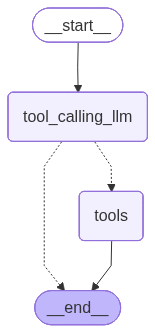

In [14]:
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode,tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
response = graph.invoke({"messages": "what is the latest ai news"})
response["messages"][-1].content

'{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.itnews.com.au/news/openais-latest-ai-models-codex-now-available-on-amazon-bedrock-625436", "title": "OpenAI\'s latest AI models, Codex now available on Amazon Bedrock - iTnews", "score": 0.70483154, "published_date": "Tue, 28 Apr 2026 20:42:00 GMT", "content": "## OpenAI\'s latest AI models, Codex now available on Amazon Bedrock ## Australia to charge Big Tech companies two percent levy unless they strike local news deals ## Alleged \'Hafnium\' hacker-for-hire extradited to the United States ## Lion to embed AI across its operations ## NAB is building an \\"AI science\\" team. # OpenAI\'s latest AI models, Codex now available on Amazon Bedrock. OpenAI is now offering its latest AI \u2060models and \u2060its Codex coding agent on Amazon\'s cloud services platform, a day after the ChatGPT creator loosened its ties with long-time backer Microsoft. OpenAI is also rolling

In [16]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the latest ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (aeb42m358)
 Call ID: aeb42m358
  Args:
    query: latest AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.itnews.com.au/news/openais-latest-ai-models-codex-now-available-on-amazon-bedrock-625436", "title": "OpenAI's latest AI models, Codex now available on Amazon Bedrock - iTnews", "score": 0.70483154, "published_date": "Tue, 28 Apr 2026 20:42:00 GMT", "content": "## OpenAI's latest AI models, Codex now available on Amazon Bedrock ## Australia to charge Big Tech companies two percent levy unless they strike local news deals ## Alleged 'Hafnium' hacker-for-hi

In [17]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (b848b96jn)
 Call ID: b848b96jn
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [18]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (w2pg8t27t)
 Call ID: w2pg8t27t
  Args:
    query: AI news
    time_range: week
    topic: news
  multiply (0c82tdnvp)
 Call ID: 0c82tdnvp
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/video/2026/04/29/ai-is-a-structural-tailwind-for-the-infrastructure-focused-nutanix.html", "title": "AI is a structural tailwind for the infrastructure-focused Nutanix: CEO - CNBC", "score": 0.595987, "published_date": "Wed, 29 Apr 2026 04:50:48 GMT", "content": "# AI is a structural tailwind for the infrastructure-focused Nutanix: CEO. CEO Rajiv Ramaswami says hy

## ReAct Agent Architecture

ReAct means the agent alternates between reasoning with the LLM and acting with tools. The key difference from the previous graph is the edge from `tools` back to `tool_calling_llm`. After tools run, their results are appended to `messages`, then the LLM sees those tool results and can either call another tool or produce the final answer.


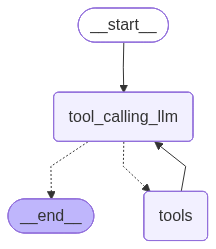

In [19]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (hnyk1mzwg)
 Call ID: hnyk1mzwg
  Args:
    include_images: True
    query: recent AI news
    time_range: week
  multiply (a8yrjw6j2)
 Call ID: a8yrjw6j2
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": ["https://vilmate.com/wp-content/uploads/2024/10/latest-updates-o-AI.png.webp", "https://cdn.prod.website-files.com/67166bf779ba8852260f7d1f/694a731a76c9d6876ddf8a8f_latest-ai-news-and-updates.png", "https://www.rollingstone.com/wp-content/uploads/2023/12/AI-newsroom.jpg?w=1581&h=1054&crop=1"], "results": [{"url": "https://matthewrenze.com/news/recent-ai-news", "title": "Recent AI News 

## Adding Memory In Agentic Graph

`MemorySaver` adds short-term memory to the graph by saving checkpoints after each run. When we compile the graph with `checkpointer=memory`, LangGraph can reload the previous state instead of treating every call as a brand-new conversation.

The `thread_id` inside `config` is the key that tells LangGraph which conversation history to continue. If two calls use the same `thread_id`, the second call can see messages from the first call. Without that config, the model only sees the messages passed into the current `graph.invoke`, so it cannot answer follow-up questions like "what is my name?" from an earlier turn.


In [22]:
response = graph.invoke(
    {"messages": "Hello, my name is Khaled"}
)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, my name is Khaled
================================== Ai Message ==================================

Hello Khaled! How can I assist you today?


In [23]:
response = graph.invoke(
    {"messages": "what is my name?"}
)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

I don't have access to personal information about users unless it's explicitly provided in the query. If you'd like me to include your name in a search or analysis, please share it with me directly in your question. The tools available to me (search engine and calculator) don't have access to personal identifiers.


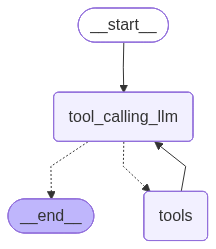

In [24]:
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode,tools_condition

# memory 
from langgraph.checkpoint.memory import MemorySaver


memory = MemorySaver()

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
# This config tells LangGraph which conversation thread to use.
# Calls with the same thread_id share the same saved memory/checkpoints.
# Change the thread_id when you want to start a separate conversation.
config = {
    "configurable":{"thread_id":"1"}
}

In [26]:
response = graph.invoke(
    {"messages": "hello my name is khaled"},
    config=config
)

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

hello my name is khaled
================================== Ai Message ==================================

Hello Khaled! How can I assist you today? Feel free to ask me any questions or let me know if there's something specific you'd like to discuss. 😊


In [27]:
response = graph.invoke(
    {"messages": "what is my name?"},
    config=config
)

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

hello my name is khaled
================================== Ai Message ==================================

Hello Khaled! How can I assist you today? Feel free to ask me any questions or let me know if there's something specific you'd like to discuss. 😊
================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

Your name is Khaled. You mentioned it earlier. How can I assist you today?


In [28]:
response['messages'][-1].content

'Your name is Khaled. You mentioned it earlier. How can I assist you today?'

## Streaming

Streaming lets us see the graph's progress while it is running instead of waiting for the final result from `invoke()`. This is useful for chatbots because the user can start seeing output sooner, and it is also useful for debugging because we can inspect what each graph step returns.

In this section we build a simple memory-enabled graph with one node named `bot`. The node receives the current `messages`, sends them to the LLM, and returns the LLM response back into the graph state. Because the graph is compiled with a `MemorySaver` checkpointer, calls that use the same `thread_id` can continue the same conversation history.


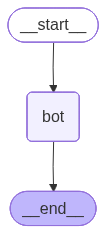

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

def bot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

graph=StateGraph(State)

graph.add_node("bot",bot)

graph.add_edge(START,"bot")
graph.add_edge("bot",END)


graph_builder=graph.compile(checkpointer=memory)


from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [36]:
# The thread_id chooses which saved conversation memory to use.
config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke(
    {'messages':"Hi,My name is ،khaled And I like cricket"}
    ,config
    )

{'messages': [HumanMessage(content='Hi,My name is ،khaled And I like cricket', additional_kwargs={}, response_metadata={}, id='b8055cde-a653-4231-9221-712c651443dd'),
  AIMessage(content="<think>\nOkay, the user introduced themselves as Khaled and mentioned they like cricket. I need to respond appropriately. First, I should welcome them by name and acknowledge their interest in cricket. Maybe ask them a few questions to keep the conversation going. Let me check if there are any common greetings or phrases in Arabic that might be relevant, but since the user wrote their name in the format they did, maybe they're comfortable with English. I should keep the tone friendly and open. Also, consider possible topics related to cricket they might be interested in, like specific teams, players, or events. Avoid making assumptions but provide options for them to elaborate. Let me make sure the response is concise and not too long. Alright, time to put it all together.\n</think>\n\nHi Khaled! Welc

## Streaming

LangGraph gives us a few ways to stream a graph run:

- `.stream()` is the synchronous streaming method. Use it with a normal `for` loop.
- `.astream()` is the asynchronous version of `.stream()`. Use it with `async for` when your code is async.
- `.astream_events()` streams lower-level events, such as model token chunks, chain starts, chain ends, and graph node events. This is useful when you want detailed tracing or token-by-token behavior.

`stream_mode` controls what each streamed chunk contains:

- `stream_mode="updates"` returns only the changes produced by each node. In this graph, the `bot` node returns a new AI message, so the streamed chunk is shaped like `{"bot": {"messages": [...]}}`.
- `stream_mode="values"` returns the full graph state after each step. Because our state has one key, `messages`, each streamed chunk contains the whole message history available at that point.

The `config` still matters during streaming. If we pass the same `thread_id`, the stream continues the same saved conversation. If we use a new `thread_id`, LangGraph starts a separate memory thread.


In [ ]:
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream(
    {'messages':"Hi,My name is khaled And I like cricket"},
    config,
    stream_mode="updates"
    ):
    print(chunk)

{'bot': {'messages': [AIMessage(content="<think>\nOkay, the user is Khaled and he likes cricket. I should respond in a friendly and welcoming way. Maybe start with a greeting and acknowledge his name. Since he mentioned cricket, I can ask him what he likes about the sport or if he plays. I should also consider if there's anything specific he wants to know or talk about. Let me make sure the tone is positive and engaging. Also, check for any spelling or grammar mistakes. Alright, time to put it all together.\n</think>\n\nHi Khaled! Nice to meet you. Cricket is an amazing sport—do you follow a particular team or enjoy playing it yourself? I'd love to hear more about what you enjoy about the game! 🏏", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 148, 'prompt_tokens': 19, 'total_tokens': 167, 'completion_time': 0.336367745, 'completion_tokens_details': None, 'prompt_time': 0.000869339, 'prompt_tokens_details': None, 'queue_time': 0.053055731, 'total_time': 

In [ ]:
# stream_mode="values" shows the full state after each step.
# Since this uses the same config as above, the graph keeps using thread_id="3" memory.
for chunk in graph_builder.stream(
    {'messages':"Hi,My name is khaled And I like football"},
    config,
    stream_mode="values"
    ):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is khaled And I like cricket', additional_kwargs={}, response_metadata={}, id='8519f14d-b9c7-48e2-a87d-277bcc15dfb6'), AIMessage(content="<think>\nOkay, the user is Khaled and he likes cricket. I should respond in a friendly and welcoming way. Maybe start with a greeting and acknowledge his name. Since he mentioned cricket, I can ask him what he likes about the sport or if he plays. I should also consider if there's anything specific he wants to know or talk about. Let me make sure the tone is positive and engaging. Also, check for any spelling or grammar mistakes. Alright, time to put it all together.\n</think>\n\nHi Khaled! Nice to meet you. Cricket is an amazing sport—do you follow a particular team or enjoy playing it yourself? I'd love to hear more about what you enjoy about the game! 🏏", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 148, 'prompt_tokens': 19, 'total_tokens': 167, 'completion_time': 0.33

In [34]:
# Another streamed call on the same thread.
# With values mode, the printed chunk includes the accumulated messages state.
for chunk in graph_builder.stream(
    {'messages':"I also like handball"},
    config,
    stream_mode="values"
    ):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is khaled And I like cricket', additional_kwargs={}, response_metadata={}, id='8519f14d-b9c7-48e2-a87d-277bcc15dfb6'), AIMessage(content="<think>\nOkay, the user is Khaled and he likes cricket. I should respond in a friendly and welcoming way. Maybe start with a greeting and acknowledge his name. Since he mentioned cricket, I can ask him what he likes about the sport or if he plays. I should also consider if there's anything specific he wants to know or talk about. Let me make sure the tone is positive and engaging. Also, check for any spelling or grammar mistakes. Alright, time to put it all together.\n</think>\n\nHi Khaled! Nice to meet you. Cricket is an amazing sport—do you follow a particular team or enjoy playing it yourself? I'd love to hear more about what you enjoy about the game! 🏏", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 148, 'prompt_tokens': 19, 'total_tokens': 167, 'completion_time': 0.33

In [ ]:
# Use a new thread_id so this async streaming example has its own memory.
config = {
    "configurable": {"thread_id": "5"}
    }

# astream_events gives detailed runtime events instead of only graph state.
# For example, on_chat_model_stream events contain token/message chunks from the LLM.
# version="v2" asks LangGraph to use the newer event schema.
async for event in graph_builder.astream_events(
    {"messages":["Hi My name is khaled and I like to play cricket"]},
    config,
    version="v2"
    ):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ddafd-e1b3-7202-b775-32f1411717ef', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='6da48dd8-aa96-47e9-a5d3-891a96d92aea')]}}, 'name': 'bot', 'tags': ['graph:step:1'], 'run_id': '019ddafd-e1b4-7e12-bf56-a274ef4ba409', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'bot', 'langgraph_triggers': ('branch:to:bot',), 'langgraph_path': ('__pregel_pull', 'bot'), 'langgraph_checkpoint_ns': 'bot:57fa33ae-2bd2-02cd-2b85-fd88eb7a667a'}, 'parent_ids': ['019ddafd-e1b3-7202-b775-32f1411717ef']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='

In [ ]:
# This streams low-level runtime events from the graph.
# We filter for on_chat_model_stream so we only print the LLM text chunks.

event_config = {
    "configurable": {"thread_id": "6"}
}

async for event in graph_builder.astream_events(
    {"messages": ["Give me one short sentence about cricket"]},
    event_config,
    version="v2"
):
    if event["event"] == "on_chat_model_stream":
        chunk = event["data"]["chunk"]
        if chunk.content:
            print(chunk.content, end="")

<think>
Okay, the user wants a short sentence about cricket. Let me think... They might be looking for something that captures the essence of the game. Maybe mention the key elements like batting, bowling, and fielding. Also, cricket is known for its strategy and teamwork. Should I include something about the different formats like Test, ODI, T20? Hmm, the sentence needs to be concise. Let me try: "Cricket is a dynamic sport blending strategy, skill, and teamwork, where batsmen face bowlers in a battle of wits and precision." That's a bit long. Let me shorten it. Maybe remove "blending strategy" and focus on the core aspects. How about: "Cricket is a strategic team sport where batsmen and bowlers duel in a test of skill, precision, and patience." Still a bit wordy. Let me make it simpler. "Cricket is a team sport combining batting, bowling, and fielding in a strategic contest of skill and endurance." That's better. Check if it's short enough. Yes, and it covers the main elements.
</thi